<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [8]:
import urllib.request
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite'
urllib.request.urlretrieve(url, 'survey-results-public.sqlite')
print("Database file downloaded successfully")

Database file downloaded successfully


#### 2. Connect to the Database


**Install the needed libraries**


In [1]:
%pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


In [4]:

# Define helper functions to parse numeric and age values
def parse_numeric_value(value):
    """Convert string values with currency symbols and K/M suffixes to numeric values."""
    if pd.isna(value) or value == '':
        return None
    if isinstance(value, (int, float)):
        return float(value)
    
    value_str = str(value).strip().upper()
    # Remove currency symbols
    value_str = value_str.replace('$', '').replace('€', '').replace('£', '')
    # Remove commas
    value_str = value_str.replace(',', '')
    
    try:
        if 'K' in value_str:
            return float(value_str.replace('K', '')) * 1000
        elif 'M' in value_str:
            return float(value_str.replace('M', '')) * 1000000
        else:
            return float(value_str)
    except ValueError:
        return None

def parse_age_value(value):
    """Convert age range strings to numeric values (middle of range)."""
    if pd.isna(value) or value == '':
        return None
    if isinstance(value, (int, float)):
        return float(value)
    
    value_str = str(value).strip()
    
    # Parse age ranges like "18-24", "25-34", etc.
    if '-' in value_str:
        try:
            parts = value_str.split('-')
            low = float(parts[0].strip())
            high = float(parts[1].strip())
            return (low + high) / 2
        except (ValueError, IndexError):
            return None
    
    # Try to parse as a single number
    try:
        return float(value_str)
    except ValueError:
        return None


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [10]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


#### Demo 3: Group Data by Age


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


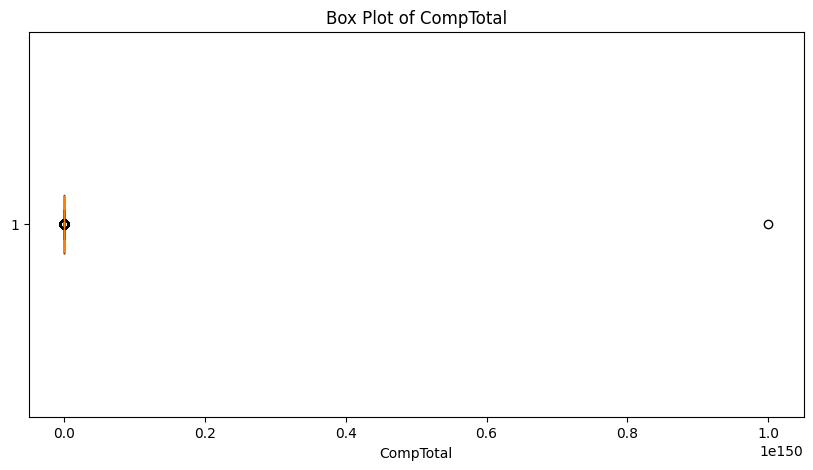

In [11]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)

df_comp['CompTotal_num'] = df_comp['CompTotal'].apply(parse_numeric_value)
df_comp = df_comp.dropna(subset=['CompTotal_num'])

plt.figure(figsize=(10, 5))
plt.boxplot(df_comp['CompTotal_num'], vert=False)
plt.title('Box Plot of CompTotal')
plt.xlabel('CompTotal')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


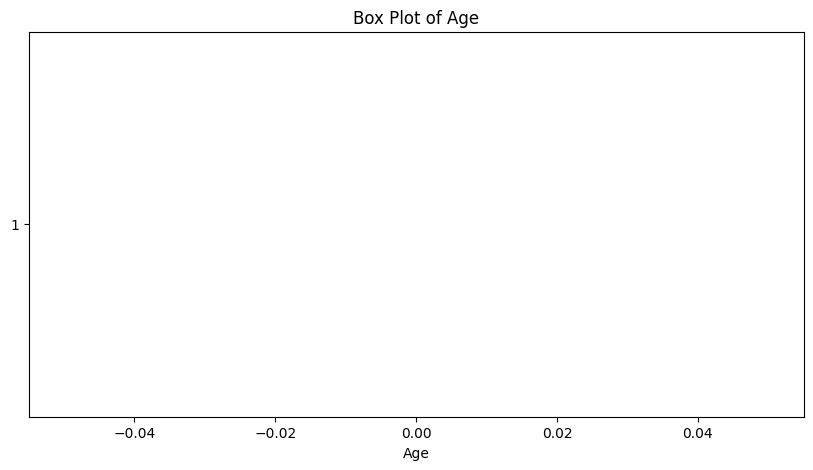

In [12]:
# your code goes here
# Task 1.2: Box Plot of Age (converted to numeric values)

QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""
df_age = pd.read_sql_query(QUERY, conn)

df_age['Age_num'] = df_age['Age'].apply(parse_age_value)
df_age = df_age.dropna(subset=['Age_num'])

plt.figure(figsize=(10, 5))
plt.boxplot(df_age['Age_num'], vert=False)
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


C:\Users\rushi\AppData\Local\Temp\ipykernel_11760\3502569257.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(age_group_data, labels=['<25', '25-34', '35-44', '45-54', '55+'], showfliers=True)


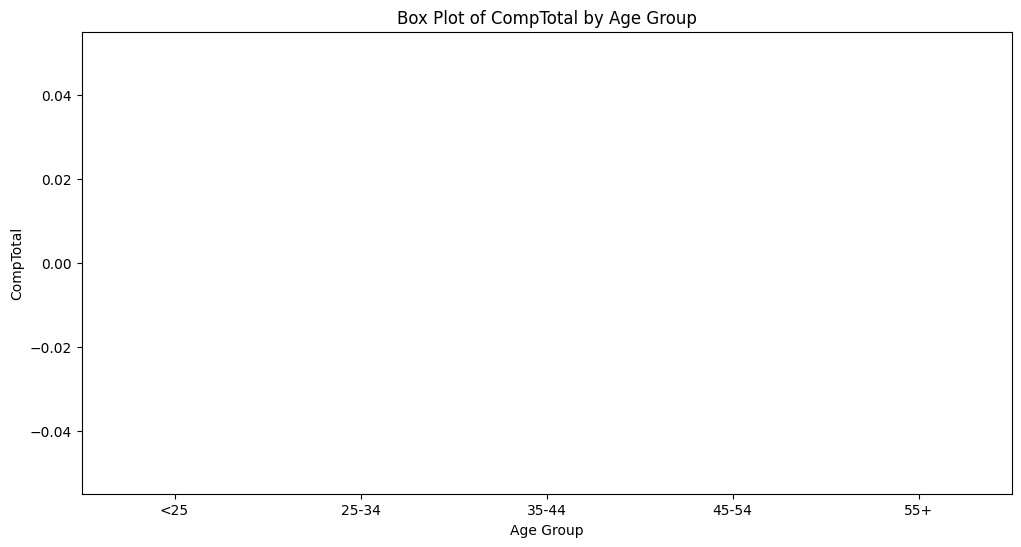

In [13]:
# Task 2.1: Box Plot of CompTotal Grouped by Age Groups

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
"""
df_age_comp = pd.read_sql_query(QUERY, conn)

df_age_comp['Age_num'] = df_age_comp['Age'].apply(parse_age_value)
df_age_comp['CompTotal_num'] = df_age_comp['CompTotal'].apply(parse_numeric_value)
df_age_comp = df_age_comp.dropna(subset=['Age_num', 'CompTotal_num'])

df_age_comp['AgeGroup'] = pd.cut(
    df_age_comp['Age_num'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55+'],
    right=False
)

age_group_data = [
    df_age_comp[df_age_comp['AgeGroup'] == group]['CompTotal_num']
    for group in ['<25', '25-34', '35-44', '45-54', '55+']
]

plt.figure(figsize=(12, 6))
plt.boxplot(age_group_data, labels=['<25', '25-34', '35-44', '45-54', '55+'], showfliers=True)
plt.title('Box Plot of CompTotal by Age Group')
plt.xlabel('Age Group')
plt.ylabel('CompTotal')
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [8]:
# Task 2.2: Box Plot of CompTotal Grouped by Job Satisfaction (JobSatPoints_6)

QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df_jobsat_comp = pd.read_sql_query(QUERY, conn)

df_jobsat_comp['CompTotal_num'] = df_jobsat_comp['CompTotal'].apply(parse_numeric_value)
df_jobsat_comp['JobSatPoints_6_num'] = df_jobsat_comp['JobSatPoints_6'].apply(parse_numeric_value)
df_jobsat_comp = df_jobsat_comp.dropna(subset=['CompTotal_num', 'JobSatPoints_6_num'])

job_levels = sorted(df_jobsat_comp['JobSatPoints_6_num'].unique())
job_data = [
    df_jobsat_comp[df_jobsat_comp['JobSatPoints_6_num'] == level]['CompTotal_num']
    for level in job_levels
]

plt.figure(figsize=(12, 6))
plt.boxplot(job_data, labels=job_levels, showfliers=True)
plt.title('Box Plot of CompTotal by JobSatPoints_6')
plt.xlabel('JobSatPoints_6')
plt.ylabel('CompTotal')
plt.show()

DatabaseError: Execution failed on sql '
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL
': no such table: main

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [9]:
# Task 3.1: Box Plot of ConvertedCompYearly for the Top 5 Developer Types

QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL AND ConvertedCompYearly IS NOT NULL
"""
df_dev = pd.read_sql_query(QUERY, conn)

df_dev['ConvertedCompYearly_num'] = df_dev['ConvertedCompYearly'].apply(parse_numeric_value)
df_dev = df_dev.dropna(subset=['ConvertedCompYearly_num'])

df_dev = df_dev.assign(DevType=df_dev['DevType'].str.split(';')).explode('DevType')
df_dev['DevType'] = df_dev['DevType'].str.strip()

top_5_devtypes = df_dev['DevType'].value_counts().head(5).index.tolist()
df_dev_top = df_dev[df_dev['DevType'].isin(top_5_devtypes)]

devtype_data = [
    df_dev_top[df_dev_top['DevType'] == dev]['ConvertedCompYearly_num']
    for dev in top_5_devtypes
]

plt.figure(figsize=(14, 6))
plt.boxplot(devtype_data, labels=top_5_devtypes, showfliers=True)
plt.title('Box Plot of ConvertedCompYearly for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

DatabaseError: Execution failed on sql '
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL AND ConvertedCompYearly IS NOT NULL
': no such table: main

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


C:\Users\rushi\AppData\Local\Temp\ipykernel_11760\897308586.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(country_data, labels=top_5_countries, showfliers=True)


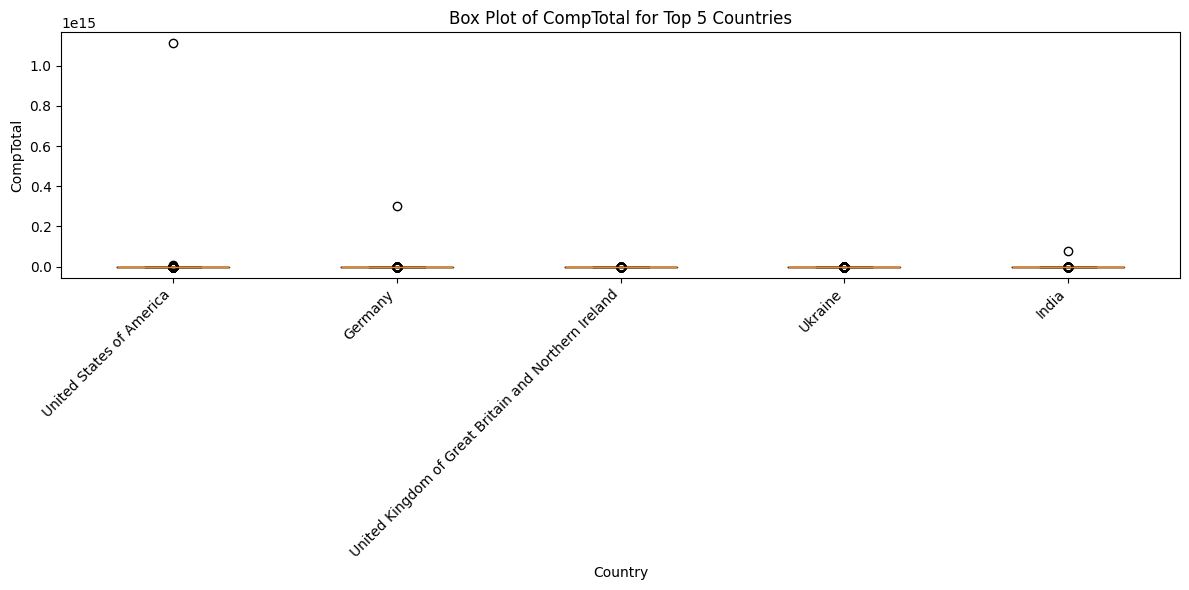

In [14]:
# Task 3.2: Box Plot of CompTotal for the Top 5 Countries

QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL AND CompTotal IS NOT NULL
"""
df_country = pd.read_sql_query(QUERY, conn)

df_country['CompTotal_num'] = df_country['CompTotal'].apply(parse_numeric_value)
df_country = df_country.dropna(subset=['CompTotal_num'])

top_5_countries = df_country['Country'].value_counts().head(5).index.tolist()
df_country_top = df_country[df_country['Country'].isin(top_5_countries)]

country_data = [
    df_country_top[df_country_top['Country'] == country]['CompTotal_num']
    for country in top_5_countries
]

plt.figure(figsize=(12, 6))
plt.boxplot(country_data, labels=top_5_countries, showfliers=True)
plt.title('Box Plot of CompTotal for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('CompTotal')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


C:\Users\rushi\AppData\Local\Temp\ipykernel_11760\4104705149.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(employment_data, labels=top_employment, showfliers=True)


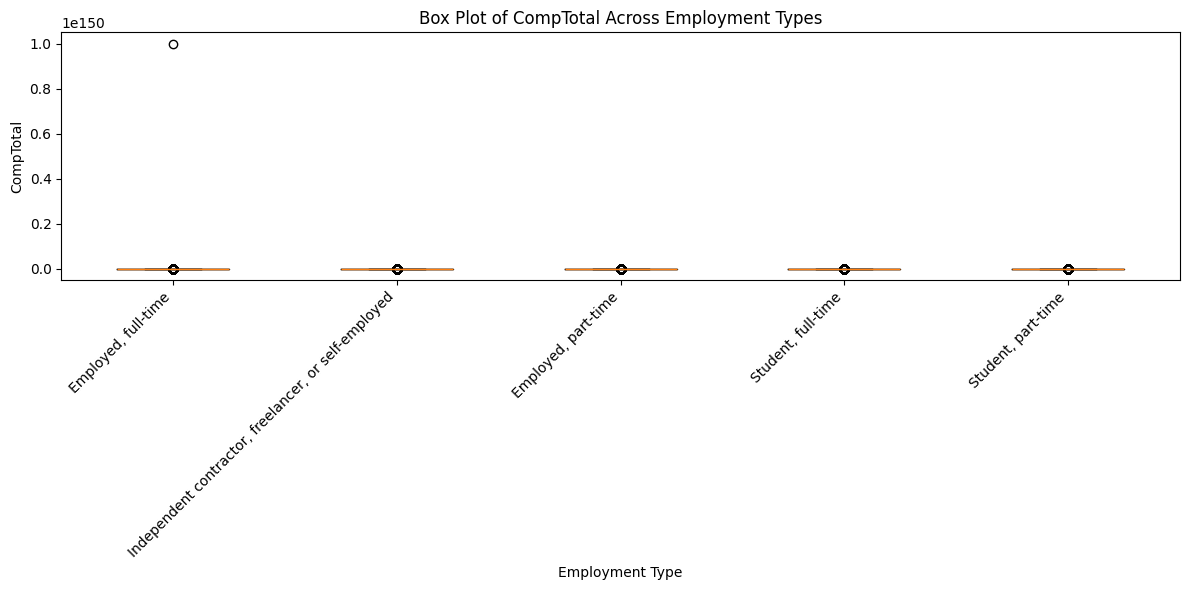

In [15]:
# Task 4.1: Box Plot of CompTotal Across Employment Types

QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL AND CompTotal IS NOT NULL
"""
df_emp = pd.read_sql_query(QUERY, conn)

df_emp['CompTotal_num'] = df_emp['CompTotal'].apply(parse_numeric_value)
df_emp = df_emp.dropna(subset=['CompTotal_num'])

df_emp = df_emp.assign(Employment=df_emp['Employment'].str.split(';')).explode('Employment')
df_emp['Employment'] = df_emp['Employment'].str.strip()

top_employment = df_emp['Employment'].value_counts().head(5).index.tolist()
df_emp_top = df_emp[df_emp['Employment'].isin(top_employment)]

employment_data = [
    df_emp_top[df_emp_top['Employment'] == emp]['CompTotal_num']
    for emp in top_employment
]

plt.figure(figsize=(12, 6))
plt.boxplot(employment_data, labels=top_employment, showfliers=True)
plt.title('Box Plot of CompTotal Across Employment Types')
plt.xlabel('Employment Type')
plt.ylabel('CompTotal')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


C:\Users\rushi\AppData\Local\Temp\ipykernel_11760\1445693983.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(exp_data, labels=job_levels_exp, showfliers=True)


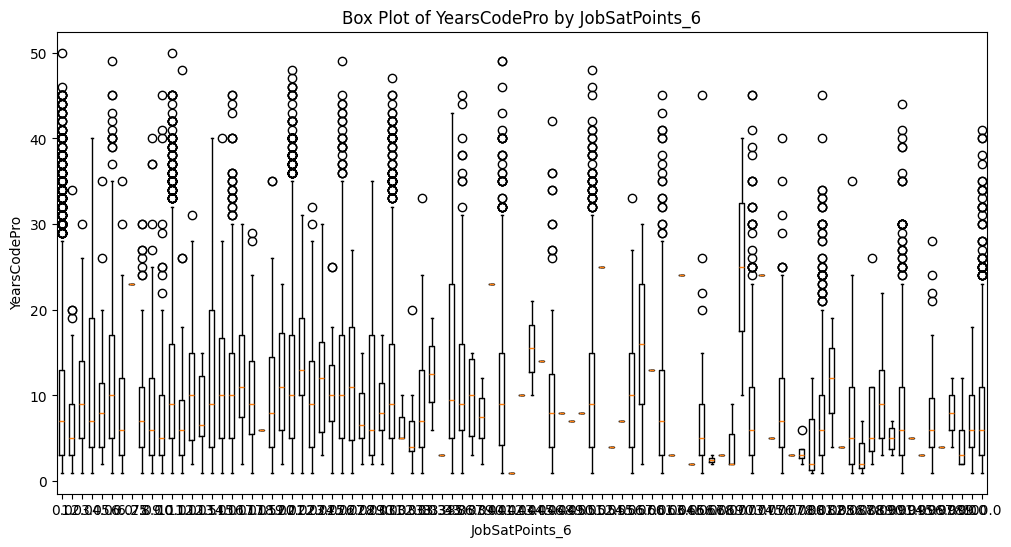

In [16]:
# Task 4.2: Box Plot of YearsCodePro by Job Satisfaction (JobSatPoints_6)

QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df_exp_sat = pd.read_sql_query(QUERY, conn)

df_exp_sat['YearsCodePro_num'] = df_exp_sat['YearsCodePro'].apply(parse_numeric_value)
df_exp_sat['JobSatPoints_6_num'] = df_exp_sat['JobSatPoints_6'].apply(parse_numeric_value)
df_exp_sat = df_exp_sat.dropna(subset=['YearsCodePro_num', 'JobSatPoints_6_num'])

job_levels_exp = sorted(df_exp_sat['JobSatPoints_6_num'].unique())
exp_data = [
    df_exp_sat[df_exp_sat['JobSatPoints_6_num'] == level]['YearsCodePro_num']
    for level in job_levels_exp
]

plt.figure(figsize=(12, 6))
plt.boxplot(exp_data, labels=job_levels_exp, showfliers=True)
plt.title('Box Plot of YearsCodePro by JobSatPoints_6')
plt.xlabel('JobSatPoints_6')
plt.ylabel('YearsCodePro')
plt.show()

### Final Step: Close the Database Connection


In [ ]:
conn.close()

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [ ]:
import urllib.request
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite'
urllib.request.urlretrieve(url, 'survey-results-public.sqlite')
print("Database file downloaded successfully")

#### 2. Connect to the Database


**Install the needed libraries**


In [ ]:
%pip install pandas

In [ ]:
%pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\rushi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [ ]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


DatabaseError: Execution failed on sql 'SELECT COUNT(*) FROM main': no such table: main

#### Demo 2: List All Tables


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


#### Demo 3: Group Data by Age


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [ ]:
# your code goes here
# Task 1.1: Box Plot of CompTotal

QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)

df_comp['CompTotal_num'] = df_comp['CompTotal'].apply(parse_numeric_value)
df_comp = df_comp.dropna(subset=['CompTotal_num'])

plt.figure(figsize=(10, 5))
plt.boxplot(df_comp['CompTotal_num'], vert=False)
plt.title('Box Plot of CompTotal')
plt.xlabel('CompTotal')
plt.show()

DatabaseError: Execution failed on sql '
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
': no such table: main

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [ ]:
# your code goes here
# Task 1.2: Box Plot of Age (converted to numeric values)

QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""
df_age = pd.read_sql_query(QUERY, conn)

df_age['Age_num'] = df_age['Age'].apply(parse_age_value)
df_age = df_age.dropna(subset=['Age_num'])

plt.figure(figsize=(10, 5))
plt.boxplot(df_age['Age_num'], vert=False)
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

DatabaseError: Execution failed on sql '
SELECT Age
FROM main
WHERE Age IS NOT NULL
': no such table: main

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [ ]:
# Task 2.1: Box Plot of CompTotal Grouped by Age Groups

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
"""
df_age_comp = pd.read_sql_query(QUERY, conn)

df_age_comp['Age_num'] = df_age_comp['Age'].apply(parse_age_value)
df_age_comp['CompTotal_num'] = df_age_comp['CompTotal'].apply(parse_numeric_value)
df_age_comp = df_age_comp.dropna(subset=['Age_num', 'CompTotal_num'])

df_age_comp['AgeGroup'] = pd.cut(
    df_age_comp['Age_num'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55+'],
    right=False
)

age_group_data = [
    df_age_comp[df_age_comp['AgeGroup'] == group]['CompTotal_num']
    for group in ['<25', '25-34', '35-44', '45-54', '55+']
]

plt.figure(figsize=(12, 6))
plt.boxplot(age_group_data, labels=['<25', '25-34', '35-44', '45-54', '55+'], showfliers=True)
plt.title('Box Plot of CompTotal by Age Group')
plt.xlabel('Age Group')
plt.ylabel('CompTotal')
plt.show()

DatabaseError: Execution failed on sql '
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
': no such table: main

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [ ]:
# Task 2.2: Box Plot of CompTotal Grouped by Job Satisfaction (JobSatPoints_6)

QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df_jobsat_comp = pd.read_sql_query(QUERY, conn)

df_jobsat_comp['CompTotal_num'] = df_jobsat_comp['CompTotal'].apply(parse_numeric_value)
df_jobsat_comp['JobSatPoints_6_num'] = df_jobsat_comp['JobSatPoints_6'].apply(parse_numeric_value)
df_jobsat_comp = df_jobsat_comp.dropna(subset=['CompTotal_num', 'JobSatPoints_6_num'])

job_levels = sorted(df_jobsat_comp['JobSatPoints_6_num'].unique())
job_data = [
    df_jobsat_comp[df_jobsat_comp['JobSatPoints_6_num'] == level]['CompTotal_num']
    for level in job_levels
]

plt.figure(figsize=(12, 6))
plt.boxplot(job_data, labels=job_levels, showfliers=True)
plt.title('Box Plot of CompTotal by JobSatPoints_6')
plt.xlabel('JobSatPoints_6')
plt.ylabel('CompTotal')
plt.show()

DatabaseError: Execution failed on sql '
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL
': no such table: main

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [ ]:
# Task 3.1: Box Plot of ConvertedCompYearly for the Top 5 Developer Types

QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL AND ConvertedCompYearly IS NOT NULL
"""
df_dev = pd.read_sql_query(QUERY, conn)

df_dev['ConvertedCompYearly_num'] = df_dev['ConvertedCompYearly'].apply(parse_numeric_value)
df_dev = df_dev.dropna(subset=['ConvertedCompYearly_num'])

df_dev = df_dev.assign(DevType=df_dev['DevType'].str.split(';')).explode('DevType')
df_dev['DevType'] = df_dev['DevType'].str.strip()

top_5_devtypes = df_dev['DevType'].value_counts().head(5).index.tolist()
df_dev_top = df_dev[df_dev['DevType'].isin(top_5_devtypes)]

devtype_data = [
    df_dev_top[df_dev_top['DevType'] == dev]['ConvertedCompYearly_num']
    for dev in top_5_devtypes
]

plt.figure(figsize=(14, 6))
plt.boxplot(devtype_data, labels=top_5_devtypes, showfliers=True)
plt.title('Box Plot of ConvertedCompYearly for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

DatabaseError: Execution failed on sql '
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL AND ConvertedCompYearly IS NOT NULL
': no such table: main

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [ ]:
# Task 3.2: Box Plot of CompTotal for the Top 5 Countries

QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL AND CompTotal IS NOT NULL
"""
df_country = pd.read_sql_query(QUERY, conn)

df_country['CompTotal_num'] = df_country['CompTotal'].apply(parse_numeric_value)
df_country = df_country.dropna(subset=['CompTotal_num'])

top_5_countries = df_country['Country'].value_counts().head(5).index.tolist()
df_country_top = df_country[df_country['Country'].isin(top_5_countries)]

country_data = [
    df_country_top[df_country_top['Country'] == country]['CompTotal_num']
    for country in top_5_countries
]

plt.figure(figsize=(12, 6))
plt.boxplot(country_data, labels=top_5_countries, showfliers=True)
plt.title('Box Plot of CompTotal for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('CompTotal')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

DatabaseError: Execution failed on sql '
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL AND CompTotal IS NOT NULL
': no such table: main

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [ ]:
# Task 4.1: Box Plot of CompTotal Across Employment Types

QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL AND CompTotal IS NOT NULL
"""
df_emp = pd.read_sql_query(QUERY, conn)

df_emp['CompTotal_num'] = df_emp['CompTotal'].apply(parse_numeric_value)
df_emp = df_emp.dropna(subset=['CompTotal_num'])

df_emp = df_emp.assign(Employment=df_emp['Employment'].str.split(';')).explode('Employment')
df_emp['Employment'] = df_emp['Employment'].str.strip()

top_employment = df_emp['Employment'].value_counts().head(5).index.tolist()
df_emp_top = df_emp[df_emp['Employment'].isin(top_employment)]

employment_data = [
    df_emp_top[df_emp_top['Employment'] == emp]['CompTotal_num']
    for emp in top_employment
]

plt.figure(figsize=(12, 6))
plt.boxplot(employment_data, labels=top_employment, showfliers=True)
plt.title('Box Plot of CompTotal Across Employment Types')
plt.xlabel('Employment Type')
plt.ylabel('CompTotal')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

DatabaseError: Execution failed on sql '
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL AND CompTotal IS NOT NULL
': no such table: main

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
